# Adversarial Patch Attack (Physical-World, EOT)

Every attack elsewhere in this repo perturbs the *entire* image by a small amount, invisible unless you go looking for it. An **adversarial patch** (Brown et al., 2017) takes the opposite approach: a small, visually obvious sticker, trained once and reusable on any input, robust enough to survive being printed, rotated, and viewed from different distances and lighting conditions. That robustness comes from **Expectation over Transformation** (EOT, Athalye et al., 2018): during training the patch is optimized against a whole distribution of random transforms, not a single fixed placement.

**Narrative:** we target **TrafficNet (GTSRB)**, the same model used in `defenses/04_adversarial_training.ipynb`, and reproduce the threat model made famous by Eykholt et al. (2018, *"Robust Physical-World Attacks on Deep Learning Visual Classification"*): a patch placed on a **Stop sign** that makes the classifier report a different, non-stopping class instead. Unlike the original paper (which optimizes a full-sign perturbation), we train a small, localized patch, closer to a real bumper sticker.


In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

### Setup: Model and Stop-Sign Images
We reuse the GTSRB data downloaded for `defenses/04_adversarial_training.ipynb` (`defenses/gtsrb_data/`, git-ignored) and the existing `traffic_sign_model.h5`. Only class 14 (`Stop`) is used here, both as the attack's training images and as its held-out evaluation set.

In [2]:
GTSRB_DIR = '../../defenses/gtsrb_data'
TRAIN_DIR = os.path.join(GTSRB_DIR, 'Train')
NUM_CLASSES = 43
TARGET_SIZE = (224, 224)

signnames_df = pd.read_csv(os.path.join(GTSRB_DIR, 'signnames.csv'))
CLASS_NAMES = dict(zip(signnames_df['ClassId'], signnames_df['SignName']))

SOURCE_CLASS = 14  # Stop
TARGET_CLASS = 35  # Ahead only - the worst-case misreading of a Stop sign for a self-driving system
print(f"Attack goal: make a '{CLASS_NAMES[SOURCE_CLASS]}' sign be classified as '{CLASS_NAMES[TARGET_CLASS]}'")

if not os.path.isdir(TRAIN_DIR):
    raise FileNotFoundError(
        f"'{TRAIN_DIR}' not found. Download and extract the GTSRB dataset from "
        "https://zenodo.org/records/13741936/files/data.zip into 'defenses/gtsrb_data/' first "
        "(same dataset used by defenses/04_adversarial_training.ipynb)."
    )

baseline_model = tf.keras.models.load_model('../../dashboard/models/traffic_sign_model.h5')
baseline_model.trainable = False  # the attack optimizes the patch, never the model

Attack goal: make a 'Stop' sign be classified as 'Ahead only'


In [3]:
def load_gtsrb_image(path):
    img_raw = tf.io.read_file(path)
    img = tf.image.decode_png(img_raw, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, TARGET_SIZE)
    return img / 255.0  # matches preprocess_gtsrb() in dashboard/utils/model_loader.py

STOP_SIGN_IMAGES_TRAIN = 80
STOP_SIGN_IMAGES_EVAL = 20

stop_sign_paths = sorted(glob.glob(os.path.join(TRAIN_DIR, str(SOURCE_CLASS), '*.png')))
rng = np.random.default_rng(seed=42)
rng.shuffle(stop_sign_paths)

train_paths = stop_sign_paths[:STOP_SIGN_IMAGES_TRAIN]
eval_paths = stop_sign_paths[STOP_SIGN_IMAGES_TRAIN:STOP_SIGN_IMAGES_TRAIN + STOP_SIGN_IMAGES_EVAL]
print(f"Stop-sign images - train: {len(train_paths)}, held-out eval: {len(eval_paths)}")

train_images = tf.stack([load_gtsrb_image(p) for p in train_paths])
eval_images = tf.stack([load_gtsrb_image(p) for p in eval_paths])

Stop-sign images - train: 80, held-out eval: 20


### Patch Application with Expectation over Transformation
Every time the patch is applied, its size, rotation, brightness, and position are all re-sampled at random, the model never sees the exact same placement twice. A patch that survives this random sampling is far more likely to survive the far messier conditions of the real world (camera angle, weather, print quality) than one optimized against a single fixed placement.

In [4]:
PATCH_SIZE_FRAC = 0.20  # patch side length as a fraction of the image size

patch_rotate = tf.keras.layers.RandomRotation(factor=0.08, fill_mode='constant', fill_value=0.0)
patch_brightness = tf.keras.layers.RandomBrightness(factor=0.2, value_range=(0.0, 1.0))

def apply_patch_eot(image, patch):
    """Pastes an EOT-augmented copy of `patch` onto `image` at a random scale, rotation, brightness and position."""
    img_h, img_w = image.shape[0], image.shape[1]
    base_size = int(img_h * PATCH_SIZE_FRAC)

    scale = tf.random.uniform([], 0.85, 1.15)
    size = tf.cast(base_size * scale, tf.int32)

    p = tf.image.resize(patch, (size, size))
    p = patch_rotate(p[None])[0]
    p = patch_brightness(p[None])[0]
    p = tf.clip_by_value(p, 0.0, 1.0)

    pos_x = tf.random.uniform([], 0, img_w - size, dtype=tf.int32)
    pos_y = tf.random.uniform([], 0, img_h - size, dtype=tf.int32)

    pad_top, pad_bottom = pos_y, img_h - pos_y - size
    pad_left, pad_right = pos_x, img_w - pos_x - size
    patch_full = tf.pad(p, [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]])
    mask_full = tf.pad(tf.ones_like(p), [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]])

    return image * (1.0 - mask_full) + patch_full * mask_full

def apply_patch_eot_batch(images, patch):
    return tf.stack([apply_patch_eot(img, patch) for img in tf.unstack(images)])

### Training Objective
The patch $\delta$ is the only thing being optimized. Everything else (model weights, image content) stays fixed. We minimize the expected classification loss towards the target class over the whole transformation distribution $T$:
$$\delta^* = \arg\min_{\delta} \; \mathbb{E}_{x \sim X,\, t \sim T} \Big[ J\big(\theta,\, \mathrm{apply}(x, \delta, t),\, y_{target}\big) \Big]$$
This is the mirror image of every other attack in the repo: instead of an $\varepsilon$-bounded perturbation added to one specific image, it is an unbounded, reusable region trained once against many images and transforms.

In [5]:
PATCH_EPOCHS = 8
PATCH_BATCH_SIZE = 8
PATCH_LEARNING_RATE = 0.05

patch = tf.Variable(tf.random.uniform((int(TARGET_SIZE[0] * PATCH_SIZE_FRAC),) * 2 + (3,), 0.0, 1.0))
optimizer = tf.keras.optimizers.Adam(learning_rate=PATCH_LEARNING_RATE)
target_label = tf.reshape(tf.one_hot(TARGET_CLASS, NUM_CLASSES), (1, NUM_CLASSES))
loss_object = tf.keras.losses.CategoricalCrossentropy()

train_ds = tf.data.Dataset.from_tensor_slices(train_images).shuffle(len(train_images), seed=42).batch(PATCH_BATCH_SIZE)

print("Training adversarial patch...")
for epoch in range(PATCH_EPOCHS):
    epoch_losses = []
    for batch in train_ds:
        with tf.GradientTape() as tape:
            patched_batch = apply_patch_eot_batch(batch, patch)
            preds = baseline_model(patched_batch, training=False)
            batch_target = tf.repeat(target_label, tf.shape(batch)[0], axis=0)
            loss = loss_object(batch_target, preds)
        grad = tape.gradient(loss, [patch])
        optimizer.apply_gradients(zip(grad, [patch]))
        patch.assign(tf.clip_by_value(patch, 0.0, 1.0))
        epoch_losses.append(float(loss))
    print(f"  Epoch {epoch + 1}/{PATCH_EPOCHS} - avg loss: {np.mean(epoch_losses):.4f}")

Training adversarial patch...


  Epoch 1/8 - avg loss: 20.5715


  Epoch 2/8 - avg loss: 16.7654


  Epoch 3/8 - avg loss: 12.3604


  Epoch 4/8 - avg loss: 8.5419


  Epoch 5/8 - avg loss: 6.8696


  Epoch 6/8 - avg loss: 7.2215


  Epoch 7/8 - avg loss: 4.9977


  Epoch 8/8 - avg loss: 6.7951


### Attack Success Rate on Held-Out Stop Signs
We apply the trained patch, with fresh EOT sampling, to the stop-sign images that were never used during patch training, and measure how often the model reports the target class instead of `Stop`.

In [6]:
N_EOT_TRIALS = 10  # random placements per eval image, to average out EOT sampling noise

successes, total = 0, 0
for img in eval_images:
    for _ in range(N_EOT_TRIALS):
        patched = apply_patch_eot(img, patch)[None]
        pred_idx = int(tf.argmax(baseline_model(patched, training=False)[0]))
        successes += int(pred_idx == TARGET_CLASS)
        total += 1

asr = 100 * successes / total
print(f"Patch Attack Success Rate on held-out Stop signs: {asr:.1f}% ({successes}/{total} random placements)")

Patch Attack Success Rate on held-out Stop signs: 47.5% (95/200 random placements)


### Visualizing the Patch
The trained patch itself, and a handful of example placements on held-out Stop signs, each with the model's resulting prediction.

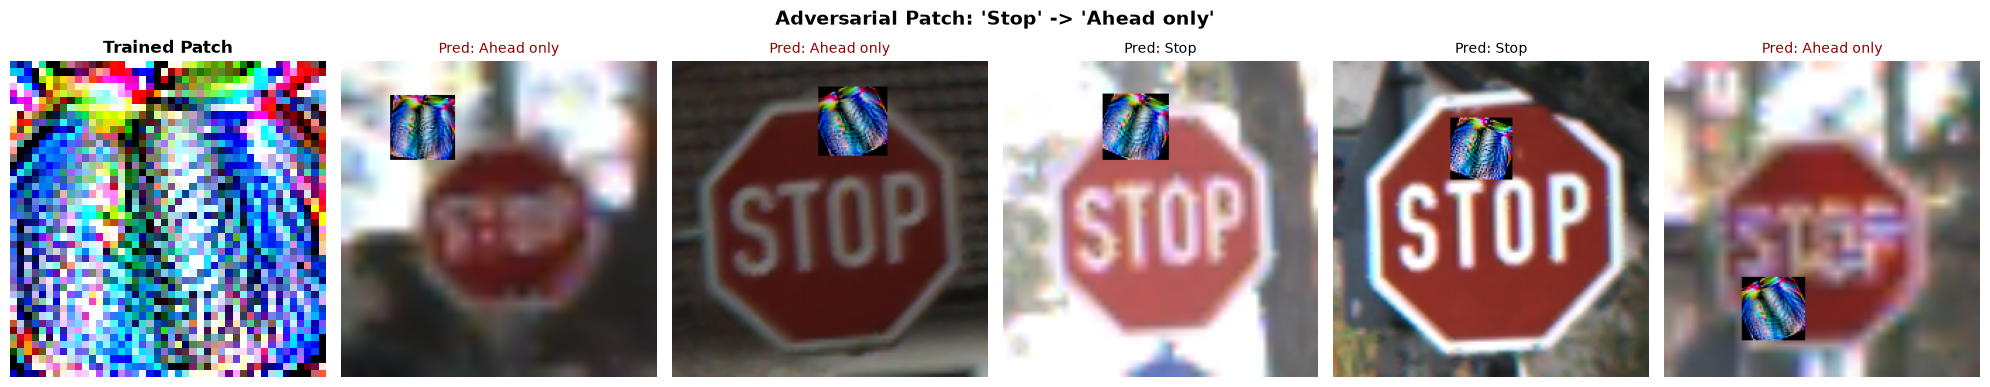

In [7]:
fig, axes = plt.subplots(1, 6, figsize=(20, 4))

axes[0].imshow(patch.numpy())
axes[0].set_title('Trained Patch', fontweight='bold')
axes[0].axis('off')

for i, ax in enumerate(axes[1:]):
    img = eval_images[i % len(eval_images)]
    patched = apply_patch_eot(img, patch)
    pred_idx = int(tf.argmax(baseline_model(patched[None], training=False)[0]))
    ax.imshow(patched.numpy())
    ax.set_title(f"Pred: {CLASS_NAMES.get(pred_idx, pred_idx)}", fontsize=10,
                 color='darkred' if pred_idx == TARGET_CLASS else 'black')
    ax.axis('off')

plt.suptitle(f"Adversarial Patch: '{CLASS_NAMES[SOURCE_CLASS]}' -> '{CLASS_NAMES[TARGET_CLASS]}'", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()